<a href="https://colab.research.google.com/github/marginagonzales1992-png/Mis-Practicas/blob/main/Practica_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tiempo medio de espera: 1.064
Utilización del servidor: 0.667


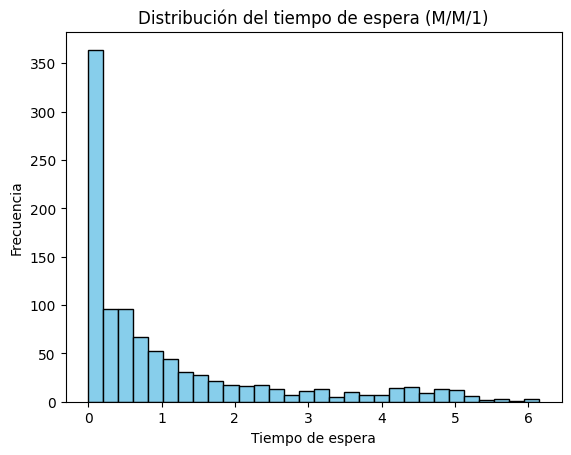

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del sistema
lambda_ = 2.0   # tasa de llegada (clientes por unidad de tiempo)
mu = 3.0        # tasa de servicio (clientes atendidos por unidad de tiempo)
n_clientes = 1000

# Generar tiempos entre llegadas y tiempos de servicio
tiempos_llegada = np.random.exponential(1/lambda_, n_clientes)
tiempos_servicio = np.random.exponential(1/mu, n_clientes)

# Calcular tiempos de llegada acumulados
llegadas = np.cumsum(tiempos_llegada)

# Inicializar variables
inicio_servicio = np.zeros(n_clientes)
fin_servicio = np.zeros(n_clientes)
tiempo_espera = np.zeros(n_clientes)

# Simulación del proceso de cola
for i in range(n_clientes):
    if i == 0:
        inicio_servicio[i] = llegadas[i]
    else:
        inicio_servicio[i] = max(llegadas[i], fin_servicio[i-1])
    fin_servicio[i] = inicio_servicio[i] + tiempos_servicio[i]
    tiempo_espera[i] = inicio_servicio[i] - llegadas[i]

# Resultados
print(f"Tiempo medio de espera: {np.mean(tiempo_espera):.3f}")
print(f"Utilización del servidor: {lambda_/mu:.3f}")

# Visualización
plt.hist(tiempo_espera, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribución del tiempo de espera (M/M/1)")
plt.xlabel("Tiempo de espera")
plt.ylabel("Frecuencia")
plt.show()

# Nueva sección